# 6.3 Build an Evaluation Set

**This is the core graded exercise of the chapter.** The rule it teaches:

> Before you trust an agent with a task, build the evaluation set that measures it.

You already believe this rule for models — Chapter 3 made you evaluate every classifier against a held-out test set with ground truth, and the class leaderboard scored you on data you never saw. An agent is a model with tools. Same rule, same machinery: define the task precisely, assemble cases with known answers, score automatically, study the failures. The difference is that *you* now generate the ground truth, and this is exactly why physically motivated synthetic data has run through this whole course: `mlgeo_synth` gives you unlimited eval cases with free, exact truth.

We work one example end to end, then you repeat the procedure on a task from your own project domain.

The target agent task:

> **Given a raw daily GNSS displacement series, report the secular velocity in mm/yr and flag any coseismic offset.**

A note on plumbing: the "agent" in this notebook is a Python function standing in for a real one, with realistic failure modes, so the notebook runs offline and in CI. The spec, the eval set, the scorer, and the loop are exactly what you would wrap around a live agent — but a live, sampled LLM agent adds three requirements the deterministic stand-in does not: validate its output schema before scoring (Step 3), run repeated trials per case and report pass rates ("Scoring without computable truth," below), and track cost and latency. This notebook builds the first two; the third is bookkeeping.

🖥️ [**Lecture slides — Session 19 (Fri Nov 13)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec19_eval_sets_for_agents.html)

## Step 1: Write the task spec

Most "agent failures" are specification failures. A spec is not a wish ("analyze this GNSS data"); it is a contract precise enough that pass/fail is computable. Ours, version 1:

In [1]:
SPEC_V1 = """
TASK: GNSS series characterization, spec v1

INPUT: a DataFrame with columns `date` (daily) and `disp_mm` (one component,
millimeters). No other columns may be used.

OUTPUT: a dict with exactly these keys:
  velocity_mm_yr : float  — secular velocity
  offset         : bool   — True if a coseismic offset is present
  offset_day     : int or None — day index of the offset if offset is True

TOLERANCES (a case passes only if ALL hold):
  |velocity_mm_yr - truth| <= 1.5 mm/yr
  offset flag matches truth
  if an offset exists and is flagged: |offset_day - truth| <= 30 days
"""
print(SPEC_V1)


TASK: GNSS series characterization, spec v1

INPUT: a DataFrame with columns `date` (daily) and `disp_mm` (one component,
millimeters). No other columns may be used.

OUTPUT: a dict with exactly these keys:
  velocity_mm_yr : float  — secular velocity
  offset         : bool   — True if a coseismic offset is present
  offset_day     : int or None — day index of the offset if offset is True

TOLERANCES (a case passes only if ALL hold):
  |velocity_mm_yr - truth| <= 1.5 mm/yr
  offset flag matches truth
  if an offset exists and is flagged: |offset_day - truth| <= 30 days



Note what is pinned down: input columns (so the agent cannot peek at truth columns), output schema (so scoring is mechanical), and numeric tolerances (so "pass" is not a mood). Note also what we did *not* think about yet — record length, noise level, offset size. The eval set is about to punish us for that, which is the point of building it.

## Step 2: Generate the eval set

Twelve cases sweeping difficulty: clean baselines, strong seasonal signal, low signal-to-noise, offsets from large to tiny, short records, and a negative velocity so sign conventions get tested. Each case is a generator call plus its ground truth — which we know because we set it.

In [2]:
import numpy as np
import pandas as pd
from mlgeo_synth import gnss_series

CASES = [
    # (case_id, description, generator parameters)
    ("C01", "clean, 10 yr, no offset",
     dict(n_years=10, velocity_mm_yr=12, eq_day=None, seed=101)),
    ("C02", "clean, 10 yr, 25 mm offset",
     dict(n_years=10, velocity_mm_yr=12, eq_day=1500, coseismic_mm=25, postseismic_mm=0, seed=102)),
    ("C03", "strong seasonal (8 mm), no offset",
     dict(n_years=10, velocity_mm_yr=6, annual_mm=8, eq_day=None, seed=103)),
    ("C04", "strong seasonal, 20 mm offset",
     dict(n_years=10, velocity_mm_yr=6, annual_mm=8, eq_day=2000, coseismic_mm=20, postseismic_mm=0, seed=104)),
    ("C05", "low SNR, no offset",
     dict(n_years=10, velocity_mm_yr=3, white_mm=3, flicker_mm=6, eq_day=None, seed=105)),
    ("C06", "low SNR, 25 mm offset",
     dict(n_years=10, velocity_mm_yr=3, white_mm=3, flicker_mm=6, eq_day=1500, coseismic_mm=25, postseismic_mm=0, seed=106)),
    ("C07", "small offset, 8 mm",
     dict(n_years=10, velocity_mm_yr=12, eq_day=1500, coseismic_mm=8, postseismic_mm=0, seed=107)),
    ("C08", "very small offset, 4 mm",
     dict(n_years=10, velocity_mm_yr=12, eq_day=1500, coseismic_mm=4, postseismic_mm=0, seed=108)),
    ("C09", "short record, 2 yr, no offset",
     dict(n_years=2, velocity_mm_yr=12, eq_day=None, seed=109)),
    ("C10", "short record, 2 yr, 25 mm offset",
     dict(n_years=2, velocity_mm_yr=12, eq_day=365, coseismic_mm=25, postseismic_mm=0, seed=110)),
    ("C11", "short + strong seasonal, no offset",
     dict(n_years=2, velocity_mm_yr=6, annual_mm=8, eq_day=None, seed=111)),
    ("C12", "negative velocity, offset near end",
     dict(n_years=10, velocity_mm_yr=-8, eq_day=3000, coseismic_mm=15, postseismic_mm=0, seed=112)),
]


def load_case(params):
    """Materialize one case: (input the agent sees, ground truth it does not)."""
    df = gnss_series(**params)
    truth = {
        "velocity_mm_yr": params["velocity_mm_yr"],
        "offset": params.get("eq_day") is not None,
        "offset_day": params.get("eq_day"),
        "n_years": params["n_years"],
    }
    return df[["date", "disp_mm"]], truth   # agent gets ONLY raw columns


print(f"{len(CASES)} cases")

12 cases


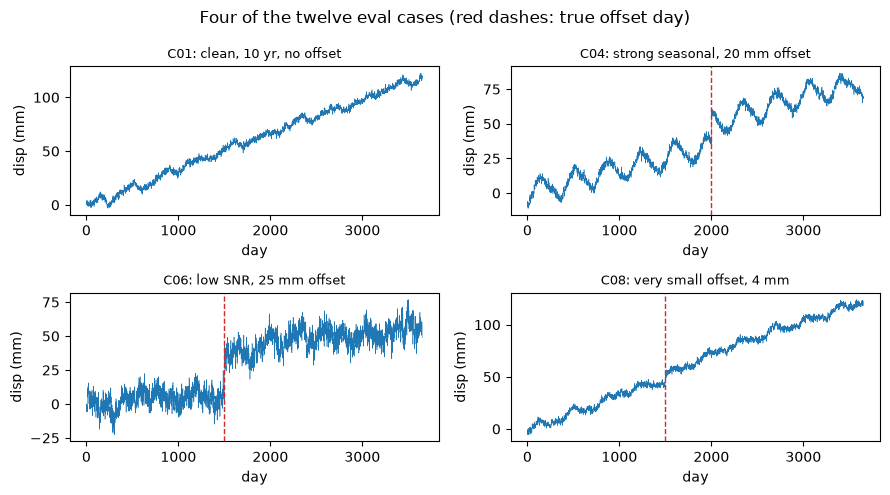

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(9, 5), sharex=False)
for ax, cid in zip(axes.ravel(), ["C01", "C04", "C06", "C08"]):
    desc, params = next((d, p) for c, d, p in CASES if c == cid)
    df, truth = load_case(params)
    ax.plot(np.arange(len(df)), df["disp_mm"], lw=0.4)
    if truth["offset"]:
        ax.axvline(truth["offset_day"], color="tab:red", ls="--", lw=1)
    ax.set_title(f"{cid}: {desc}", fontsize=9)
    ax.set_xlabel("day")
    ax.set_ylabel("disp (mm)")
fig.suptitle("Four of the twelve eval cases (red dashes: true offset day)")
fig.tight_layout()

Look at C08 before moving on: a 4 mm offset under millimeter-level colored noise is invisible to the eye. Whether the agent should be *required* to find it is a genuine scientific question — and writing the eval set forced us to ask it, before any agent ran. Coverage design in one sentence: sweep every knob that changes the physics of the problem (signal size, noise, record length, confounding signals), include cases where the correct answer is "nothing there," and include at least one case near the edge of physical detectability.

## Step 3: Write the scorer

Mechanical, tolerance-based, no judgment calls at scoring time — all the judgment went into the spec. And one non-negotiable property: **the scorer must survive malformed output.** The most common failure of a live LLM agent is not a wrong number; it is output that violates the schema — a missing key, a number wrapped in prose, a string where a float belongs. A scorer that raises `KeyError` on such output cannot record the very failure it most needs to record. So `score_case` first validates the result against the spec's output schema and converts any violation into a *scored failure with a reason*, never an exception. (The grading rubric at the end awards Scorer-soundness points for exactly this behavior — the worked exemplar now demonstrates what those points are for.)

In [4]:
RESULT_SCHEMA = {
    # key -> types the spec allows
    "velocity_mm_yr": (int, float),
    "offset": (bool, np.bool_),
    "offset_day": (int, np.integer, type(None)),
}


def validate_result(result):
    """Check an agent result against the spec's output schema.

    Returns a list of problems; an empty list means the schema holds.
    """
    if not isinstance(result, dict):
        return [f"not a dict: got {type(result).__name__}"]
    problems = [f"missing key '{k}'" for k in RESULT_SCHEMA if k not in result]
    for k, types in RESULT_SCHEMA.items():
        if k in result and not isinstance(result[k], types):
            problems.append(f"'{k}' has type {type(result[k]).__name__}")
    return problems


def score_case(result, truth, vel_tol=1.5, day_tol=30):
    """Apply the spec's tolerances to one agent result. Returns per-check booleans.

    Malformed output is a scored failure with a reason — never a crash.
    """
    problems = validate_result(result)
    if problems:
        return {"vel_ok": False, "offset_ok": False, "pass": False,
                "malformed": "; ".join(problems)}
    vel_ok = abs(result["velocity_mm_yr"] - truth["velocity_mm_yr"]) <= vel_tol
    flag_ok = bool(result["offset"]) == truth["offset"]
    day_ok = True
    if truth["offset"] and result["offset"]:
        day_ok = abs(result["offset_day"] - truth["offset_day"]) <= day_tol
    return {"vel_ok": vel_ok, "offset_ok": flag_ok and day_ok,
            "pass": vel_ok and flag_ok and day_ok, "malformed": ""}


def run_eval(agent, vel_tol_fn=lambda truth: 1.5):
    """Run an agent over all cases; return one row per case."""
    rows = []
    for case_id, desc, params in CASES:
        df, truth = load_case(params)
        result = agent(df)
        s = score_case(result, truth, vel_tol=vel_tol_fn(truth))
        valid = not s["malformed"]
        rows.append({
            "case": case_id, "description": desc,
            "true_v": truth["velocity_mm_yr"],
            "est_v": round(result["velocity_mm_yr"], 2) if valid else None,
            "true_offset": truth["offset"],
            "flagged": result["offset"] if valid else None,
            **s,
        })
    return pd.DataFrame(rows).set_index("case")

Prove the guard works before trusting it — one deliberately malformed result, of the kind a live agent produces when it wraps the number in prose and forgets a key:

In [5]:
bad_result = {"velocity_mm_yr": "about 12 mm/yr", "offset": False}  # string; no offset_day
_, truth_c01 = load_case(CASES[0][2])
score_case(bad_result, truth_c01)

{'vel_ok': False,
 'offset_ok': False,
 'pass': False,
 'malformed': "missing key 'offset_day'; 'velocity_mm_yr' has type str"}

## Step 4: Run it against the agent

Here is the simulated agent. Its strategy is the naive one a hasty (human or artificial) analyst produces: a straight-line fit for velocity, ignoring seasonal terms and offsets, and offset detection by scanning for the largest jump between 30-day means. Its failure modes are planted but realistic: velocity biased when an unmodeled signal is present, small offsets missed, noise excursions mistaken for offsets.

In [6]:
def agent_v1(df):
    """Simulated agent, version 1: straight-line velocity + jump detector."""
    d = df["disp_mm"].to_numpy()
    t_yr = np.arange(len(d)) / 365.25
    velocity = np.polyfit(t_yr, d, 1)[0]          # ignores seasonal & offsets

    best_jump, best_day = 0.0, None
    for day in range(45, len(d) - 45, 5):          # largest 30-day-mean jump
        jump = abs(d[day:day + 30].mean() - d[day - 30:day].mean())
        if jump > best_jump:
            best_jump, best_day = jump, day
    detected = best_jump > 12                      # hard-coded threshold, mm
    return {"velocity_mm_yr": velocity, "offset": detected,
            "offset_day": best_day if detected else None}


res_v1 = run_eval(agent_v1)
res_v1

,description,true_v,est_v,true_offset,flagged,vel_ok,offset_ok,pass,malformed
case,,,,,,,,,
C01,"clean, 10 yr, no offset",12,12.01,False,False,True,True,True,
C02,"clean, 10 yr, 25 mm offset",12,15.30,True,True,False,True,False,
C03,"strong seasonal (8 mm), no offset",6,5.73,False,False,True,True,True,
C04,"strong seasonal, 20 mm offset",6,8.86,True,True,False,True,False,
C05,"low SNR, no offset",3,2.33,False,True,True,False,False,
C06,"low SNR, 25 mm offset",3,7.20,True,True,False,True,False,
C07,"small offset, 8 mm",12,13.30,True,False,True,False,False,
C08,"very small offset, 4 mm",12,12.73,True,False,True,False,False,
C09,"short record, 2 yr, no offset",12,14.98,False,False,False,True,False,


In [7]:
print(f"agent v1: {int(res_v1['pass'].sum())}/12 cases pass "
      f"(velocity: {int(res_v1['vel_ok'].sum())}/12, "
      f"offset: {int(res_v1['offset_ok'].sum())}/12)")

agent v1: 3/12 cases pass (velocity: 6/12, offset: 9/12)


## Step 5: Analyze failures, tighten, re-run

Three of twelve. Without the eval set, this agent would have shipped: its answers on any single series *look* reasonable. Read the failures by group — the table is the diagnosis:

- **C02, C04, C06, C10 — velocity wrong whenever an offset is present.** The straight-line fit absorbs the unmodeled step into the slope. On the 2-year record (C10) the bias reaches ~18 mm/yr. Correlated failure mode: the two outputs are not independent, so a missed *model term* corrupts a *reported number*.
- **C07, C08 — small offsets missed.** The hard-coded 12 mm threshold cannot see 8 or 4 mm steps. The spec never said what the minimum detectable offset should be; the eval set just made that gap visible.
- **C05 — false alarm.** Flicker noise wanders enough that some 30-day means differ by >12 mm with no earthquake at all. "No offset" cases earn their place in an eval set: a detector is only meaningful if it can stay silent.
- **C09, C11 — velocity wrong on short records even with no offset.** Two years of seasonal signal plus colored noise defeat a straight-line fit.

The failure analysis dictates the fix, and it is a *spec* fix as much as an agent fix. Spec v2 adds a required method clause — "estimate velocity by least squares with annual and semi-annual terms and, if an offset is flagged, a step function at the detected day" — the physical model from Chapter 2. The improved agent implements it:

In [8]:
def agent_v2(df):
    """Simulated agent, version 2: fits trend + seasonal + step (spec v2)."""
    d = df["disp_mm"].to_numpy()
    n = len(d)
    t = np.arange(n)
    t_yr = t / 365.25

    best_jump, best_day = 0.0, None
    for day in range(45, n - 45, 5):
        jump = abs(d[day:day + 30].mean() - d[day - 30:day].mean())
        if jump > best_jump:
            best_jump, best_day = jump, day

    G = np.column_stack([
        np.ones(n), t_yr,
        np.sin(2 * np.pi * t_yr), np.cos(2 * np.pi * t_yr),
        np.sin(4 * np.pi * t_yr), np.cos(4 * np.pi * t_yr),
        (t >= best_day).astype(float),
    ])
    coef, *_ = np.linalg.lstsq(G, d, rcond=None)
    detected = abs(coef[-1]) > 6      # decide on the FITTED step amplitude
    if not detected:                   # refit without the step term
        coef, *_ = np.linalg.lstsq(G[:, :-1], d, rcond=None)
    return {"velocity_mm_yr": coef[1], "offset": detected,
            "offset_day": best_day if detected else None}


res_v2 = run_eval(agent_v2)
print(f"agent v2: {int(res_v2['pass'].sum())}/12 cases pass")
res_v2[~res_v2["pass"]]

agent v2: 10/12 cases pass


,description,true_v,est_v,true_offset,flagged,vel_ok,offset_ok,pass,malformed
case,,,,,,,,,
C09,"short record, 2 yr, no offset",12,14.01,False,False,False,True,False,
C10,"short record, 2 yr, 25 mm offset",12,10.32,True,True,False,True,False,


Ten of twelve, and every physics failure is gone: offsets down to 4 mm are found (deciding on the *fitted step amplitude* beats thresholding raw jumps), the low-SNR false alarm disappears, velocities are right wherever the model is adequate.

The two survivors — C09 and C10 — are both 2-year records, and their velocity misses (~1.7–2 mm/yr) are not the agent's fault. Velocity uncertainty from colored GNSS noise scales roughly as 1/T: two years of flicker noise cannot deliver ±1.5 mm/yr, no matter who analyzes it. Our spec demanded something the data cannot give. This is the second thing eval sets catch: **unreasonable specs.**

How far should the tolerance relax, then? Not to whatever makes the failures go away — that is grading on a curve you drew after seeing the exam. The tolerance is a property of the estimator under the physics, and we own the generator, so we can *measure* it: run the estimator on many fresh offset-free realizations at each record length and look at the distribution of its error.

In [9]:
def velocity_error_spread(n_years, n_trials=50, truth_v=12.0):
    """|velocity error| of agent_v2 over fresh offset-free realizations."""
    errs = []
    for s in range(1000, 1000 + n_trials):   # seeds disjoint from the eval set
        df = gnss_series(n_years=n_years, velocity_mm_yr=truth_v, eq_day=None, seed=s)
        est = agent_v2(df[["date", "disp_mm"]])["velocity_mm_yr"]
        errs.append(abs(est - truth_v))
    return np.array(errs)


for T in (10, 2):
    e = velocity_error_spread(T)
    print(f"{T:>2}-yr records, 50 seeds: median |error| {np.median(e):.2f} mm/yr, "
          f"95th percentile {np.quantile(e, 0.95):.2f} mm/yr")

10-yr records, 50 seeds: median |error| 0.09 mm/yr, 95th percentile 0.28 mm/yr


 2-yr records, 50 seeds: median |error| 0.78 mm/yr, 95th percentile 1.85 mm/yr


The distribution answers the question. Ten-year records: 95th-percentile error near 0.3 mm/yr, so the original ±1.5 mm/yr is comfortable. Two-year records: the 95th percentile sits near 1.9 mm/yr — ±1.5 was never achievable, and a tolerance of ±3 mm/yr (about 1.5× the measured 95th percentile, headroom because 50 trials pin the tail only loosely and we sampled a single true velocity) is what the physics supports. Spec v3 writes that measurement into the contract. The general rule: **derive tolerances from realizations of the estimator, not from a first guess** — with a synthetic generator, the derivation costs five lines.

In [10]:
def vel_tol_v3(truth):
    # 1.5 covers the measured 10-yr error spread with wide margin;
    # 3.0 ~ 1.5x the measured 95th-percentile error on 2-yr records.
    return 1.5 if truth["n_years"] >= 5 else 3.0


res_v3 = run_eval(agent_v2, vel_tol_fn=vel_tol_v3)
summary = pd.DataFrame({
    "agent v1, spec v1": res_v1["pass"],
    "agent v2, spec v2": res_v2["pass"],
    "agent v2, spec v3": res_v3["pass"],
})
print(f"final: {int(res_v3['pass'].sum())}/12")
summary

final: 12/12


,"agent v1, spec v1","agent v2, spec v2","agent v2, spec v3"
case,,,
C01,True,True,True
C02,False,True,True
C03,True,True,True
C04,False,True,True
C05,False,True,True
C06,False,True,True
C07,False,True,True
C08,False,True,True
C09,False,False,True


Twelve of twelve — and, more important, an audit trail: we know *which* capabilities were tested, *which* tolerances the physics supports, and *what* the agent could not do until its method changed. That table is what "I trust this agent with GNSS characterization" should mean.

This is the **eval-driven loop**:

1. spec → 2. eval set with ground truth → 3. scorer → 4. run → 5. failure analysis → tighten the spec or fix the agent → back to 4.

It is the same loop as model development in Chapter 3, with the eval set playing the role of the hidden test set. Two cautions transfer with it. First, an eval set you iterate against is a *validation* set; if the stakes are high, hold out fresh cases (new seeds!) for a final check, exactly as the leaderboard held out its test data. Second, the eval only covers what you put in it — our agent is validated for one-component series with at most one offset, and claiming more would be the overreach that Chapter 7.2 teaches you to write down honestly.

```{admonition} Contamination: assume the examinee can read the exam
:class: warning
The fresh-seeds caution has a sharper form for live agents. An agent with access to this repository can read `mlgeo_synth/gnss.py` — the generator source, the noise model, and every truth parameter live a few directories from the eval set, and this notebook prints its twelve seeds. An examinee that has seen the exam machinery is contaminated by construction; no intent is required — the material is simply in its context if it looks. So design evals on the assumption that the agent can see everything committed to the repo. The defense is not hiding code; it is truth the agent cannot reach: fresh private seeds (and, for high stakes, held-out parameter ranges) drawn at evaluation time and never committed.
```

## Scoring without computable truth

Everything above scored against exact numeric truth: `abs(est - truth) <= tol` settles every case. Many tasks you will actually delegate have no such number. The clearest example is the one this course is building toward: the **pre-submission review agent** you will construct from your own quality rubric, whose job is to critique a paper before you submit it. A review has no `velocity_mm_yr`. Its output is a judgment, and "is this a good review?" is itself a judgment.

The eval machinery survives, with three substitutions.

**1. The scorer becomes a rubric.** Decompose "is this review good" into binary checks a reader can settle without asking you: *names the leakage flaw*, *every criticism cites a specific line, figure, or number*, *proposes a concrete fix for each flaw*, *does not praise a defect*. You built exactly this kind of rubric in [6.2](6.2_critical_evaluation.ipynb) part (c). And the planted-truth trick from this notebook still applies: feed the review agent papers with **known, planted defects** — a leakage bug, a fabricated citation, a tuned-on-test threshold — and "found the planted flaw" becomes a computable check again. Ground truth for a subjective task is something you engineer, not something you find.

**2. You must measure whether the rubric can be applied consistently.** A rubric only functions as a scorer if two raters applying it to the same output reach the same verdicts. That is measurable: have two raters score the same output (the partner swap in 6.2 part (c) produces exactly this data) and compute their agreement. Raw percent agreement is not enough — if most checks pass, two raters agree often by chance — so report **Cohen's kappa**, agreement corrected for chance. It fits in five lines:

In [11]:
# Two raters apply the same 12-check rubric to one AI-written review
# (1 = criterion met). The 6.2 part (c) partner swap yields exactly this data.
rater_1 = np.array([1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1])
rater_2 = np.array([1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1])


def cohens_kappa(a, b):
    """Two-rater agreement corrected for chance: (p_o - p_e) / (1 - p_e)."""
    a, b = np.asarray(a), np.asarray(b)
    p_o = (a == b).mean()                                        # observed
    p_e = a.mean() * b.mean() + (1 - a.mean()) * (1 - b.mean())  # by chance
    return (p_o - p_e) / (1 - p_e)


print(f"percent agreement: {100 * (rater_1 == rater_2).mean():.0f}%   "
      f"kappa: {cohens_kappa(rater_1, rater_2):.2f}")

# Why percent agreement alone misleads: two lenient raters who pass almost
# everything agree constantly -- by chance.
lenient_1 = np.array([1] * 11 + [0])
lenient_2 = np.array([1] * 12)
print(f"lenient raters:    {100 * (lenient_1 == lenient_2).mean():.0f}%   "
      f"kappa: {cohens_kappa(lenient_1, lenient_2):.2f}")

percent agreement: 83%   kappa: 0.63
lenient raters:    92%   kappa: 0.00


Report both numbers. The first pair agrees on 83% of checks and kappa is 0.63 — real but imperfect consistency. The lenient pair agrees on 92% of checks and kappa is 0.00: every bit of that agreement is what two yes-sayers produce by chance. Low kappa is a rubric defect before it is a rater defect: each disagreement marks a criterion whose wording two readers resolved differently. Rewrite that criterion, re-score, re-measure. A rubric two humans cannot apply consistently is not ready to be handed to an LLM judge.

When the second rater *is* a model (as in 6.2 part (c), and as your review agent's own scoring will be), add the controls for the judge biases you measured there, applied at scoring time:

- **Order.** Score the pair as (A, B) and again as (B, A); a verdict that flips with position is position bias, not signal.
- **Verbosity.** Score each rubric check independently instead of asking for an overall impression — length inflates holistic scores far more than it inflates per-check answers.
- **Blinding.** Do not tell the judge which output came from your own agent, and strip any self-identifying preamble before scoring.

**3. Single verdicts become pass rates.** `agent_v2` returns the same dict on every run; a sampled LLM does not. Run a live review agent five times on the same paper and it will catch a planted flaw in some runs and miss it in others. So the per-case unit of measurement changes from pass/fail to a **pass rate with sampling uncertainty**. Below are recorded results from a review agent run N=5 times per case on six short analyses with planted defects — the transcripts were recorded once and rubric-scored, so this cell runs offline and in CI like everything else:

In [12]:
# Rubric-scored outcome of each recorded run: 1 = the review named the planted
# defect (for P03, correctly reported that nothing was planted).
recorded_runs = {
    "P01 leakage: scaler fit before split":    [1, 1, 1, 1, 1],
    "P02 threshold tuned on the test split":   [1, 1, 0, 1, 1],
    "P03 no planted flaw (negative case)":     [1, 1, 1, 1, 1],
    "P04 single seed, no spread reported":     [0, 1, 0, 1, 0],
    "P05 axis units off by 10^3 in figure":    [0, 0, 1, 0, 0],
    "P06 fabricated citation in related work": [1, 0, 1, 1, 0],
}

rows = []
for case, outcomes in recorded_runs.items():
    p = np.mean(outcomes)
    se = np.sqrt(p * (1 - p) / len(outcomes))   # binomial standard error
    rows.append({"case": case, "runs": "".join(map(str, outcomes)),
                 "pass_rate": p, "std_err": round(se, 2)})
pd.DataFrame(rows).set_index("case")

,runs,pass_rate,std_err
case,,,
P01 leakage: scaler fit before split,11111,1.0,0.00
P02 threshold tuned on the test split,11011,0.8,0.18
P03 no planted flaw (negative case),11111,1.0,0.00
"P04 single seed, no spread reported",01010,0.4,0.22
P05 axis units off by 10^3 in figure,00100,0.2,0.18
P06 fabricated citation in related work,10110,0.6,0.22


Read P04: a single-run eval would have called it pass or fail on a coin flip — run once and ship, and your conclusion about the agent depends on the draw. And the standard errors say what a difference means: at N=5, a rate near 0.5 carries ±0.22, so one agent version scoring 3/5 where another scored 2/5 on a case is not evidence of improvement. Three consequences for your capstone eval: report rates, not verdicts; fix N in the spec before running; and demand a margin larger than the standard error before believing a change helped (or increase N until the error bars separate).

Taken together — rubric checks over planted defects, two-rater kappa on the rubric itself, order/verbosity/blinding controls, pass rates over N runs — this is the complete scoring machinery for the review agent you will build in the reading arc. It grades papers instead of velocities, and nothing about that exempts it from evaluation.

## Optional: the same eval against a live model

Everything graded in this chapter runs offline: the simulated agent and the recorded transcripts are the graded baseline, and CI executes them without a network. If you have the hardware and the inclination, the same harness runs unchanged against a real open-weights model — OLMo 2, Ai2's fully open model (weights, training data, and code all released) — served locally by [Ollama](https://ollama.com):

```bash
ollama pull olmo2               # 7B default: ~4.5 GB disk; ~8 GB RAM to run; CPU works, slowly
export MLGEO_LIVE_EVAL=1        # opt in, then launch Jupyter from the same shell
```

Ollama exposes an OpenAI-compatible endpoint at `http://localhost:11434/v1`, so the "agent" below is one HTTP call. We hand the model 30-day means of the series (about 120 numbers for a 10-year record) — which is deliberately the bad-calculator setup from [6.1](6.1_llms_to_agents.md): a text engine given a regression problem. Expect schema violations and wrong velocities. That is the pedagogical point: the schema guard records the malformed outputs instead of crashing, the tolerances judge the numbers, and at nonzero sampling temperature you would need the repeated-trials machinery from the previous section. A capable live agent would instead *write and run code* on the raw series; wiring that up is a project-scale exercise, not a notebook cell.

The cell runs the live eval only when you have opted in with `MLGEO_LIVE_EVAL=1` *and* a local Ollama server has an `olmo2` model pulled; otherwise it prints a note and moves on. It cannot fail a build: no opt-in means no network call, and even an opted-in run that errors degrades to a message. Nothing in it is graded, and no assignment requires it.

In [13]:
import json
import os
import urllib.request

OLLAMA = "http://localhost:11434"


def ollama_model(prefix="olmo2"):
    """Exact tag of a pulled model matching `prefix` (e.g. 'olmo2:7b'), or None."""
    try:
        with urllib.request.urlopen(f"{OLLAMA}/api/tags", timeout=2) as r:
            tags = json.load(r)
        return next((m["name"] for m in tags.get("models", [])
                     if m["name"].startswith(prefix)), None)
    except Exception:
        return None


def ask_olmo(prompt, model):
    body = json.dumps({"model": model, "temperature": 0,
                       "messages": [{"role": "user", "content": prompt}]}).encode()
    req = urllib.request.Request(f"{OLLAMA}/v1/chat/completions", data=body,
                                 headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=600) as r:
        return json.load(r)["choices"][0]["message"]["content"]


def make_agent_olmo(model):
    def agent_olmo(df):
        """Live agent: the spec plus 30-day means of the series, JSON answer requested."""
        means = df["disp_mm"].groupby(np.arange(len(df)) // 30).mean().round(1)
        prompt = (SPEC_V1
                  + "\nDATA: consecutive 30-day means of disp_mm, in mm "
                    "(bin i covers days 30*i to 30*i + 29):\n"
                  + ", ".join(str(v) for v in means)
                  + "\nAnswer with ONLY the JSON object described under OUTPUT. "
                    "offset_day must be a day index, not a bin index.")
        text = ask_olmo(prompt, model)
        try:
            return json.loads(text[text.index("{"): text.rindex("}") + 1])
        except Exception:
            return {"unparseable_text": text}   # the schema guard scores this
    return agent_olmo


# Opt in explicitly: export MLGEO_LIVE_EVAL=1 before launching Jupyter.
# The env-var gate keeps book builds fast and deterministic even on machines
# where an Ollama server happens to be running.
live_model = ollama_model() if os.environ.get("MLGEO_LIVE_EVAL") == "1" else None
if live_model is None:
    print("Live run disabled (set MLGEO_LIVE_EVAL=1 with a local Ollama server "
          "and `ollama pull olmo2`).")
    print("The offline simulated/recorded path above is the graded baseline.")
else:
    try:
        res_live = run_eval(make_agent_olmo(live_model), vel_tol_fn=vel_tol_v3)
        print(f"{live_model} live: {int(res_live['pass'].sum())}/12 cases pass")
        display(res_live)
    except Exception as e:   # a live server that misbehaves must not kill the notebook
        print(f"Live run against {live_model} failed ({type(e).__name__}: {e}) — skipping.")

Live run disabled (set MLGEO_LIVE_EVAL=1 with a local Ollama server and `ollama pull olmo2`).
The offline simulated/recorded path above is the graded baseline.


## Assignment: an eval set for your project domain

Repeat steps 1–5 for an agent task from **your project's** domain. You choose the task; it must be one you would actually delegate. Examples to calibrate scope: "pick the P-wave arrival within ±0.1 s" (`seismogram_dataset`), "classify lithology from a geochemistry row and abstain when uncertain" (`geochem_table`), "estimate b-value from a magnitude catalog" (`gutenberg_richter_magnitudes`), "flag the rare events in this sensor series" (`inject_rare_events`).

Deliverables, in one notebook:

1. **Task spec** — inputs, output schema, tolerances, and any required method constraints. Written first, versioned if it changed. Tolerances derived from realizations where you own the generator, not guessed.
2. **Eval set** — at least 10 cases from an `mlgeo_synth` generator (or your own generator with documented ground truth), sweeping difficulty along at least three axes, including negative/"nothing there" cases and at least one case near the edge of detectability.
3. **Scorer** — mechanical, runs with one function call, and returns a scored failure (never an exception) on missing or malformed agent output, as in Step 3. Tolerance-based where truth is computable; if your task's output is a judgment, use rubric checks over planted defects instead, and report two-rater agreement (percent + kappa) on at least a subset ("Scoring without computable truth").
4. **Run + failure analysis** — run your (real or simulated) agent, group the failures, and diagnose each group: agent limitation, spec defect, or physical impossibility?
5. **Writeup** — half a page: what the eval set covers, what it deliberately does not, and what you would now trust the agent to do unsupervised.

Grading rubric (100 points):

| Criterion | Points | What earns them |
|---|---|---|
| Spec clarity | 25 | Output schema and tolerances computable without asking you; constraints justified |
| Eval-set coverage | 25 | Difficulty axes span the physics; negatives included; edge-of-detectability case present; ground truth exact |
| Scorer soundness | 20 | Pure function of (result, truth, spec); no post-hoc judgment; handles missing/malformed agent output |
| Failure analysis | 20 | Failures grouped and diagnosed, not listed; each group traced to agent, spec, or physics |
| Writeup | 10 | Honest scope statement; a reader knows exactly what remains untested |

Every rubric row is demonstrated in the worked exemplar above — the malformed-output handling that Scorer soundness asks for is Step 3's `validate_result`, and the tolerance justification that Spec clarity asks for is the 50-realization measurement before spec v3.

One warning from experience: the most common way to lose points is an eval set your agent passes 10/10 on the first try. That is not a good agent; that is an easy exam.